In [1]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
#edge_options.add_argument('--headless')
edge_options.add_argument("--disable-images")  # Disable images
edge_options.add_argument("--disable-javascript")  # Disable JavaScript
edge_options.add_argument("--disable-plugins")  # Disable plugins
edge_options.add_argument("--disable-extensions")  # Disable extensions
edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")

import warnings
warnings.filterwarnings('ignore')

url='https://www.espn.com/soccer/competitions'
driver.get(url)

In [ ]:
league_urls=[e.get_attribute('href') for e in driver.find_elements(By.CSS_SELECTOR, 'div[class="x"][role="x"] a[class="x"]')]
league_urls=list(set(league_urls))

In [ ]:
league_urls=[i for i in league_urls if '/teams/' in i]

In [ ]:
all_teams_urls=[]

for i, league_url in enumerate(league_urls, start=1):
    driver.get(league_url)
    time.sleep(2)

    teams_urls=[e.get_attribute('href') for e in driver.find_elements(By.CSS_SELECTOR ,'div[class="x"][role="x"] a[class="x"]')]
    all_teams_urls.extend(teams_urls)

    print(f'{i}/{len(league_urls)}', end='\r')
    

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
#pickle.dump(all_teams_urls, open('all_teams_urls.pickle','wb'))

In [3]:
all_teams_urls=pickle.load( open('all_teams_urls.pickle','rb'))

In [4]:
all_teams_urls=[i for i in all_teams_urls if 'fixtures/' not in i and 'stats/' not in i]
all_teams_urls=list(set(all_teams_urls))

In [5]:
all_teams_urls=[i.split('_/')[0]+"squad/_/"+i.split('_/')[-1] for i in all_teams_urls]

In [6]:
all_teams_urls=[i.replace('espn.com','espn.co.uk') for i in all_teams_urls]

In [7]:
len(all_teams_urls)

2699

In [ ]:
dfs=[]

for i, team_url in enumerate(all_teams_urls, start=1):
    if i<=1300:
        continue
    
    driver.get(team_url)
    html=driver.page_source
    
    try:
        df_gk=pd.read_html(html)[0]
        dfs.append(df_gk)
    except:
        df_gk=None

    try:
        df_op=pd.read_html(html)[1]
        dfs.append(df_op)
    except:
        df_op=None

    if i%100==0 or i==len(all_teams_urls):
        pickle.dump(dfs, open(f'dfs_{i}.pickle','wb'))
        dfs=[]
        
    
    print(f'{i}/{len(all_teams_urls)}', end='\r')

In [21]:
df=pd.DataFrame()

for i, file in enumerate(os.listdir(), start=1):
    if file.startswith('dfs'):
        tables=pickle.load(open(file,'rb'))
        for table in tables:
            df=pd.concat([df, table])

    print(i, end='\r')

30

In [23]:
df=df[['Name', 'POS', 'Age', 'HT', 'WT', 'NAT']]

In [26]:
df=df.replace('--',None)

df['HT']=df['HT'].apply(lambda x:x.replace('m','') if isinstance(x, str) else None).apply(pd.to_numeric)
df['WT']=df['WT'].apply(lambda x:x.replace('kg','') if isinstance(x, str) else None).apply(pd.to_numeric)
df['Age']=df['Age'].apply(pd.to_numeric)

<Axes: >

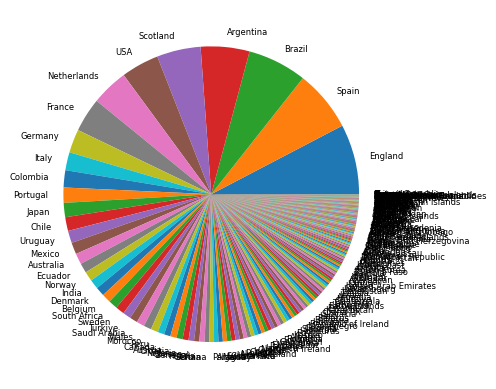

In [45]:
df['NAT'].value_counts(normalize=True).plot.pie(fontsize=6, label='')

In [47]:
df['BMI']=df['WT']/(df['HT']**2)

Text(0.5, 1.0, 'BMI Frequency Distribution')

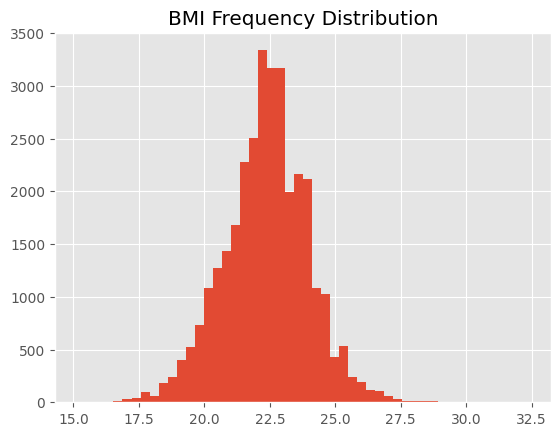

In [92]:
df.query('15<BMI<35')['BMI'].hist(bins=50)
plt.title('BMI Frequency Distribution')

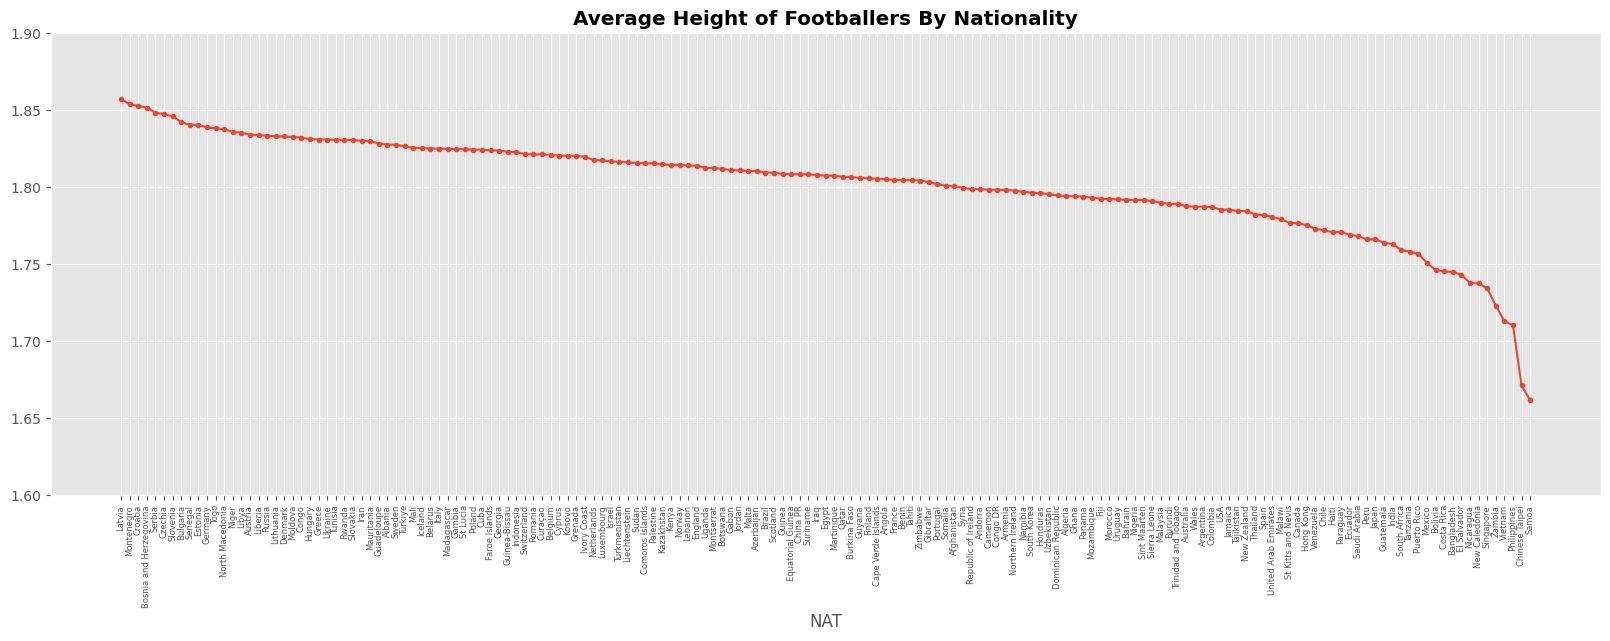

In [99]:
grouped=df.groupby('NAT').filter(lambda x:x['HT'].count()>=10)\
.groupby('NAT')['HT'].agg(
    mean='mean',
    count='count'
).sort_values('mean', ascending=False)['mean']\

plt.figure(figsize=(20,6))
grouped.plot.line(marker='.')
plt.title('Average Height of Footballers By Nationality', fontweight='bold')
plt.ylim(1.6, 1.9)
plt.xticks(range(len(grouped.index)), grouped.index, fontsize=6,rotation=90)
plt.show()

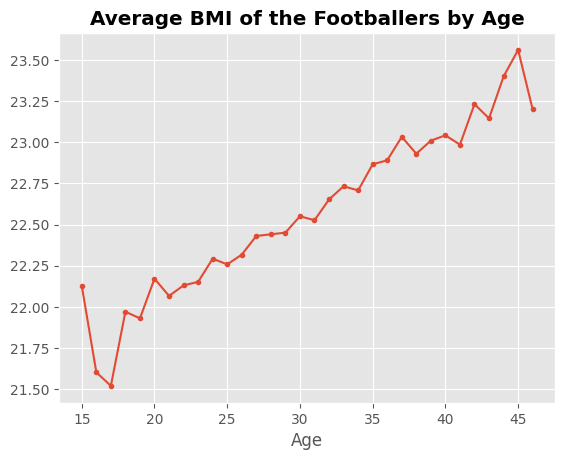

In [91]:
df.groupby('Age').filter(lambda x:x['BMI'].count()>10)\
.groupby('Age')['BMI'].mean().plot.line(marker='.')
plt.title('Average BMI of the Footballers by Age', fontweight='bold')
plt.show()